# 02 - Análise Exploratória de Dados

## 1. Importação das bibliotecas e leitura dos dados

Nesta etapa, são importadas as bibliotecas utilizadas ao longo da análise exploratória e carregado o dataset enriquecido gerado na etapa anterior do projeto.

O conjunto de dados utilizado contém informações individuais dos alunos, características territoriais e socioeconômicas dos municípios e indicadores agregados do contexto escolar.

O dataset carregado possui:

- **57.782 registros**
- **35 variáveis**

Essa etapa garante que a base enriquecida esteja disponível corretamente antes do início das validações estruturais e análises estatísticas.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

BASE_DIR = Path("..")
GOLD_DIR = BASE_DIR / "data" / "gold"

DATASET_PATH = GOLD_DIR / "gold_dataset_enriquecido.parquet"

df = pd.read_parquet(DATASET_PATH)

print("Dataset carregado com sucesso.")
print("Shape:", df.shape)

Dataset carregado com sucesso.
Shape: (57782, 35)


## 2. Validação estrutural inicial

Antes de realizar qualquer análise exploratória, é necessário verificar a consistência estrutural do dataset.

Essa validação inicial busca identificar possíveis problemas relacionados a:

- quantidade de registros e variáveis;
- tipos de dados;
- duplicidades;
- cobertura temporal;
- consistência da variável alvo;
- presença de valores ausentes.

Essas verificações são importantes para garantir que as análises posteriores sejam realizadas sobre uma base consistente e confiável.

### 2.1 Dimensão e tipos de dados

O dataset apresenta **57.782 linhas e 35 colunas**.

A inspeção dos tipos de dados mostra a presença de variáveis numéricas, categóricas e identificadores, compatíveis com a natureza heterogênea das informações utilizadas no projeto.

As variáveis incluem dados individuais dos alunos, identificadores territoriais, informações educacionais e atributos provenientes das fontes externas utilizadas no enriquecimento.

In [2]:
print(f"Total de Linhas -> {df.shape[0]}")
print(f"Total de Colunas -> {df.shape[1]}")

Total de Linhas -> 57782
Total de Colunas -> 35


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57782 entries, 0 to 57781
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ano                                 57782 non-null  Int64  
 1   id_municipio                        57782 non-null  string 
 2   id_municipio_nome                   57782 non-null  string 
 3   id_escola                           57782 non-null  string 
 4   id_aluno                            57782 non-null  string 
 5   caderno                             57782 non-null  int64  
 6   serie                               57782 non-null  string 
 7   rede                                57782 non-null  string 
 8   presenca                            57782 non-null  string 
 9   preenchimento_caderno               57782 non-null  string 
 10  alfabetizado                        57782 non-null  string 
 11  proficiencia                        48026

### 2.2 Verificação de duplicidades

A granularidade da base corresponde a registros individuais de alunos por ano.

Como o mesmo `id_aluno` pode aparecer em anos diferentes, a verificação de duplicidade foi realizada considerando a chave composta:

`ano + id_aluno`

Não foram identificadas duplicidades nessa chave.

Também não foram encontradas linhas completamente duplicadas no dataset.

Esse resultado indica que a base mantém uma granularidade consistente para as análises individuais.

In [4]:
duplicidades = df.duplicated(subset=["ano", "id_aluno"]).sum()

print(f"Duplicidades por Ano + Id_aluno -> {duplicidades}")

Duplicidades por Ano + Id_aluno -> 0


In [5]:
print(f"Linhas completamente duplicadas -> {df.duplicated().sum()}")

Linhas completamente duplicadas -> 0


### 2.3 Cobertura temporal

O dataset contém registros referentes aos anos de **2023 e 2024**.

A distribuição dos registros é:

- **2023:** 28.295 observações
- **2024:** 29.487 observações

A quantidade de registros é relativamente equilibrada entre os dois anos, permitindo comparações temporais sem grande concentração em apenas um período.

In [6]:
print(df["ano"].value_counts().sort_index())

ano
2023    28295
2024    29487
Name: count, dtype: Int64


### 2.4 Validação da variável alvo

A variável `alfabetizado` representa o desfecho principal do projeto e será posteriormente utilizada como variável alvo no modelo de classificação supervisionada.

A distribuição observada foi:

- **Não alfabetizado:** 29.535 alunos — 51,11%
- **Alfabetizado:** 28.247 alunos — 48,89%

Não foram identificados valores ausentes na variável alvo.

A distribuição das classes é bastante equilibrada, o que é favorável para a etapa de modelagem, pois reduz a necessidade de técnicas específicas para tratamento de forte desbalanceamento de classes.

In [7]:
print(f"Valores únicos do target -> {df['alfabetizado'].unique()}")

print(f"\nDistribuição:")
print(df['alfabetizado'].value_counts())

print("\nDistribuição em Percentual:")
print(df['alfabetizado'].value_counts(normalize=True).mul(100).round(2))

Valores únicos do target -> <StringArray>
['Não', 'Sim']
Length: 2, dtype: string

Distribuição:
alfabetizado
Não    29535
Sim    28247
Name: count, dtype: Int64

Distribuição em Percentual:
alfabetizado
Não    51.11
Sim    48.89
Name: proportion, dtype: Float64


### 2.5 Análise inicial de valores ausentes

A análise de valores ausentes revelou diferentes níveis de cobertura entre as variáveis.

As maiores proporções de ausência foram identificadas em:

- `meta_municipio_ano`: aproximadamente 57,18%
- `meta_uf_ano`: aproximadamente 57,18%
- `proficiencia`: aproximadamente 16,88%
- `peso_aluno`: aproximadamente 16,88%
- `percentual_participacao`: aproximadamente 13,53%

As demais variáveis apresentam cobertura elevada, com ausência inexistente ou residual.

Esses resultados serão utilizados posteriormente para definir quais variáveis serão mantidas nas análises principais e quais deverão ser descartadas por baixa cobertura, baixa relevância analítica ou risco de vazamento de informação.

In [8]:
resumo_final = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(dropna=True)
})

display(resumo_final)

,tipo,nulos,pct_nulos,valores_unicos
ano,Int64,0,0.00,2
id_municipio,string,0,0.00,4591
id_municipio_nome,string,0,0.00,4397
id_escola,string,0,0.00,24346
id_aluno,string,0,0.00,57449
caderno,int64,0,0.00,4
serie,string,0,0.00,1
rede,string,0,0.00,2
presenca,string,0,0.00,2
preenchimento_caderno,string,0,0.00,2


### 2.6 Definição das variáveis utilizadas na análise

Após a avaliação inicial da qualidade dos dados, algumas variáveis foram removidas da base utilizada no EDA principal.

As colunas excluídas foram:

- `serie`: removida por apresentar apenas um único valor em toda a base, não contribuindo para diferenciação dos registros;
- `meta_municipio_ano`: removida devido à elevada proporção de valores ausentes;
- `meta_uf_ano`: removida devido à elevada proporção de valores ausentes;
- `proficiencia`: removida por apresentar potencial vazamento de informação em relação à variável alvo `alfabetizado`;
- `peso_aluno`: removida por não representar uma característica explicativa direta do fenômeno analisado;
- `percentual_participacao`: removida por apresentar valores ausentes e menor relevância frente ao conjunto de variáveis já disponíveis.

Após essa etapa, o dataset passou de **35 para 29 variáveis**, mantendo os **57.782 registros** originais.

A remoção foi realizada apenas na cópia utilizada para análise (`df_eda`), preservando o dataset enriquecido original.

In [26]:
colunas_remover = ["serie", "meta_municipio_ano", "meta_uf_ano", "proficiencia", "peso_aluno", "percentual_participacao"]

df_eda = df.drop(columns=colunas_remover).copy()

print(f"Shape original -> {df.shape}")
print(f"Shape após a remoção das columas -> {df_eda.shape}")

print("\nColunas que foram removidas")
for colunas in colunas_remover:
    print(f"-> {colunas}")

Shape original -> (57782, 35)
Shape após a remoção das columas -> (57782, 29)

Colunas que foram removidas
-> serie
-> meta_municipio_ano
-> meta_uf_ano
-> proficiencia
-> peso_aluno
-> percentual_participacao


### 2.7 Tratamento final de valores ausentes

Após a remoção das variáveis previamente definidas, permaneceram apenas valores ausentes residuais no dataset.

A aplicação de `dropna()` resultou em:

- **57.782 registros antes do tratamento**
- **57.712 registros após o tratamento**
- **70 registros removidos**
- **0,12% de perda da base**

Como a proporção removida foi muito pequena, considerou-se adequada a exclusão desses registros.

Ao final dessa etapa, o dataset utilizado no EDA ficou totalmente livre de valores ausentes.

In [29]:
linhas_antes = len(df_eda)

df_eda_sem_nulos = df_eda.dropna().copy()

linhas_depois = len(df_eda_sem_nulos)
percentual = ((linhas_antes - linhas_depois) / linhas_antes * 100)

print(f"Linhas antes -> {linhas_antes}")
print(f"Linhas depois -> {linhas_depois}")
print(f"Linhas que foram removidas -> {linhas_antes - linhas_depois}")
print(f"Percentual removido -> {percentual:.2f}%")

Linhas antes -> 57782
Linhas depois -> 57712
Linhas que foram removidas -> 70
Percentual removido -> 0.12%


In [30]:
df_eda = df_eda.dropna()
print(f"Total de nulos -> {df_eda.isna().sum().sum()}")

Total de nulos -> 0


### 2.8 Conclusão da preparação para o EDA

A etapa de preparação e validação do dataset foi concluída com sucesso.

A base utilizada nas análises exploratórias apresenta:

- ausência de duplicidades;
- variável alvo completa e aproximadamente balanceada;
- cobertura temporal entre 2023 e 2024;
- remoção de variáveis com baixa utilidade analítica, alta ausência ou risco de vazamento de informação;
- tratamento residual de valores ausentes;
- preservação de aproximadamente 99,88% dos registros originais.

Com isso, o dataset encontra-se em condições adequadas para o início das análises exploratórias de distribuições, padrões, associações e relações entre as variáveis e o indicador de alfabetização.

## 3. Análise da variável alvo

A variável `alfabetizado` representa o desfecho principal do projeto e será utilizada como variável alvo na etapa de modelagem supervisionada.

Nesta seção, sua distribuição é analisada com o objetivo de verificar o equilíbrio entre as classes e identificar possíveis mudanças ao longo do tempo.

### 3.1 Distribuição geral da variável alvo

A distribuição da variável `alfabetizado` mostra uma base praticamente equilibrada entre as duas classes:

- **Não alfabetizado:** 29.468 registros — 51,0%
- **Alfabetizado:** 28.244 registros — 49,0%

A diferença entre as classes é pequena, indicando ausência de desbalanceamento relevante.

Esse resultado é positivo para a futura etapa de classificação, pois reduz a necessidade de técnicas específicas de reamostragem, como oversampling ou undersampling, apenas para compensar diferenças de frequência entre as classes.

In [12]:
qtd_classes = df_eda['alfabetizado'].value_counts()
percentual_classes = df_eda['alfabetizado'].value_counts(normalize=True).round(2) * 100

resumo_classes = pd.DataFrame({
    "quantidade": qtd_classes,
    "percentual": percentual_classes
})

resumo_classes

,quantidade,percentual
alfabetizado,,
Não,29468,51.0
Sim,28244,49.0


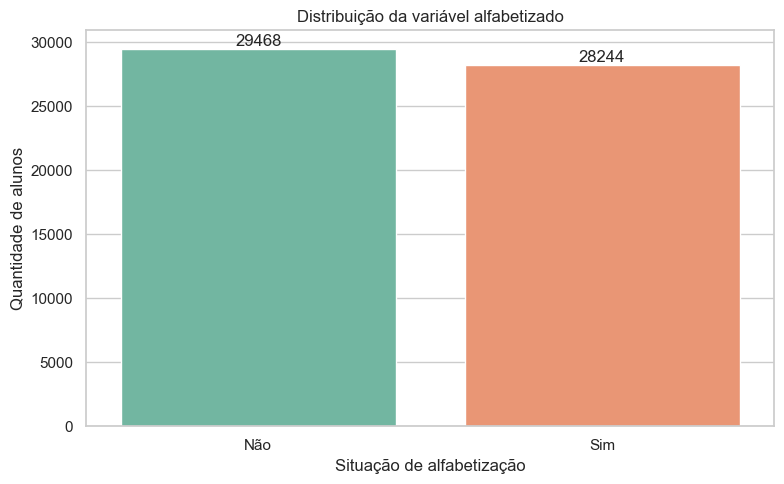

In [13]:
plt.figure(figsize=(8,5))

ax = sns.countplot(df_eda, x='alfabetizado', hue='alfabetizado', legend=False, palette='Set2')

plt.title("Distribuição da variável alfabetizado")
plt.xlabel("Situação de alfabetização")
plt.ylabel("Quantidade de alunos")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### 3.2 Evolução da alfabetização por ano

A análise temporal mostra uma pequena melhora na proporção de alunos classificados como alfabetizados entre 2023 e 2024.

Os resultados observados foram:

- **2023:** 48,23% alfabetizados
- **2024:** 49,62% alfabetizados

Isso representa um aumento de aproximadamente **1,39 ponto percentual** na taxa de alfabetização.

Apesar da melhora, a diferença entre os dois anos é relativamente pequena. Dessa forma, o ano de referência, isoladamente, não aparenta apresentar forte capacidade de separação entre alunos alfabetizados e não alfabetizados.

In [14]:
alfabetizacao_ano = pd.crosstab(
    df_eda['ano'], df_eda['alfabetizado'], normalize="index"
).mul(100).round(2)

alfabetizacao_ano

alfabetizado,Não,Sim
ano,,
2023,51.77,48.23
2024,50.38,49.62


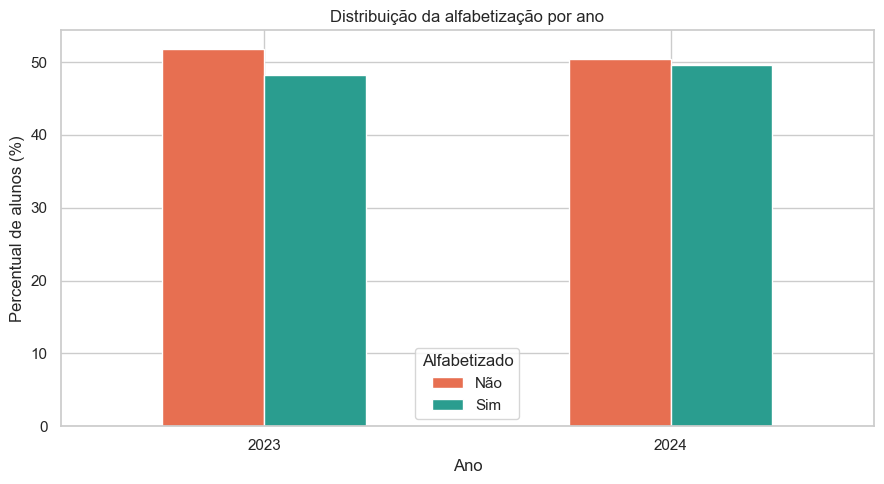

In [15]:
alfabetizacao_ano.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#e76f51", "#2a9d8f"]
)

plt.title("Distribuição da alfabetização por ano")
plt.xlabel("Ano")
plt.ylabel("Percentual de alunos (%)")
plt.xticks(rotation=0)
plt.legend(title="Alfabetizado")

plt.tight_layout()
plt.show()

## 4. Análise das variáveis numéricas

Nesta etapa são analisadas as variáveis numéricas presentes no dataset com o objetivo de compreender suas distribuições, identificar valores extremos, avaliar diferenças entre alunos alfabetizados e não alfabetizados e investigar possíveis relações com a variável alvo.

A análise também busca identificar assimetrias, redundâncias e possíveis transformações que poderão ser necessárias nas etapas posteriores de engenharia de atributos e modelagem.

In [32]:
var_numericas = (
    df_eda
    .select_dtypes(include="number")
    .columns
    .difference(
        ["ano", "caderno"]
    )
    .tolist()
)

var_numericas

['area_km2',
 'densidade_demografica',
 'media_alunos_docente_fund_ai',
 'media_alunos_turma_fund_ai',
 'media_prop_salas_climatizadas',
 'pib_per_capita',
 'populacao_2022',
 'prop_escolas_agua_potavel',
 'prop_escolas_banda_larga',
 'prop_escolas_biblioteca_leitura',
 'prop_escolas_esgoto_rede',
 'prop_escolas_internet',
 'prop_escolas_internet_aprendizagem',
 'prop_escolas_lab_informatica',
 'prop_escolas_rampas_acessibilidade',
 'prop_escolas_rurais',
 'qtd_escolas_censo']

### 4.1 Visão geral das distribuições

Inicialmente, foram analisadas as distribuições das variáveis numéricas por meio de histogramas.

A análise mostra que diversas variáveis territoriais e econômicas apresentam forte assimetria à direita, como `pib_per_capita`, `populacao_2022`, `area_km2`, `densidade_demografica` e `qtd_escolas_censo`.

Esse comportamento é esperado devido à grande heterogeneidade existente entre os municípios brasileiros, com poucos municípios apresentando valores muito superiores à maior parte da distribuição.

Também foi observada concentração elevada próxima de 1 em algumas variáveis de infraestrutura escolar, como acesso à água potável, internet e banda larga, indicando que esses recursos estão amplamente presentes nos contextos educacionais representados na base.

Já as variáveis relacionadas à quantidade média de alunos por turma e alunos por docente apresentam distribuições mais concentradas e aproximadamente unimodais.

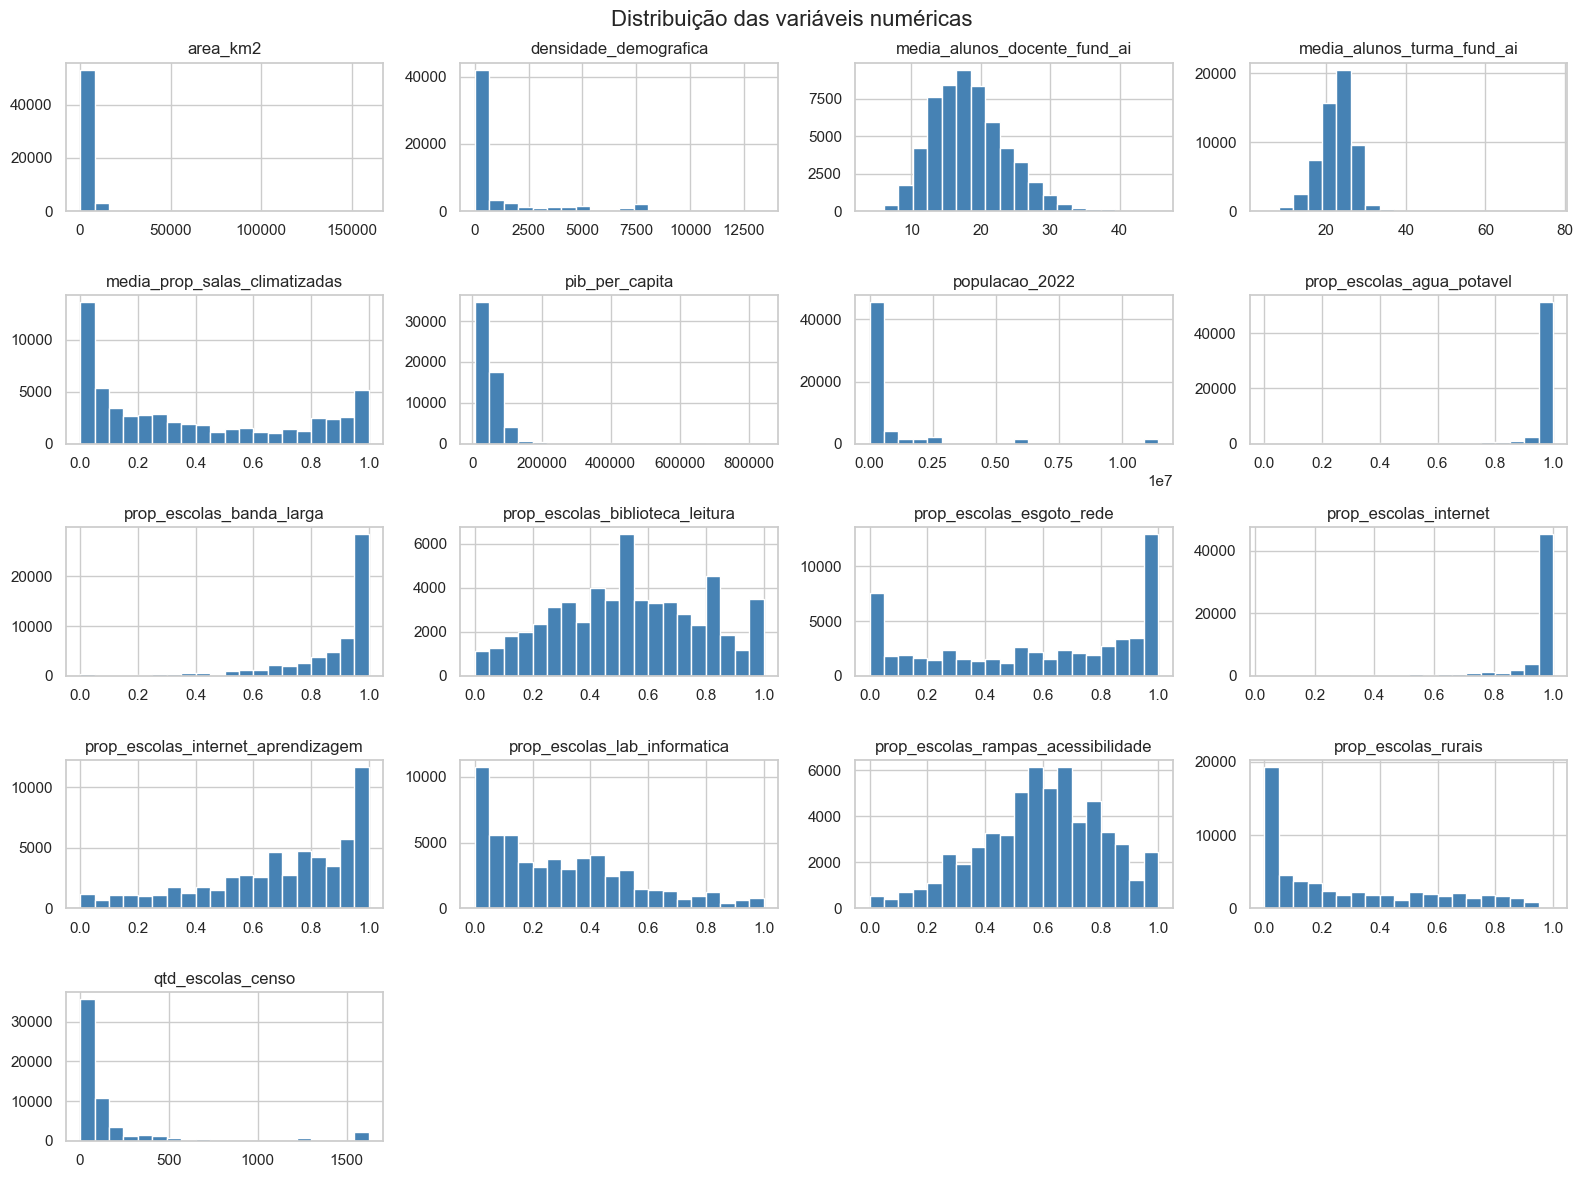

In [33]:
df_eda[var_numericas].hist(
    figsize=(16,12),
    bins=20,
    color="steelblue"
)
plt.suptitle("Distribuição das variáveis numéricas", fontsize=16)
plt.tight_layout()
plt.show()

### 4.2 Comparação das variáveis numéricas por situação de alfabetização

Para investigar possíveis diferenças entre alunos alfabetizados e não alfabetizados, foram selecionadas variáveis representativas das dimensões econômica, territorial e educacional.

Foram utilizados boxplots e curvas de densidade para comparar as distribuições entre as duas classes.

De forma geral, observa-se elevada sobreposição entre os grupos `Sim` e `Não`, indicando que nenhuma das variáveis analisadas apresenta, isoladamente, uma separação clara entre alunos alfabetizados e não alfabetizados.

Algumas diferenças sutis podem ser observadas em variáveis como infraestrutura escolar, acesso à internet para aprendizagem, acessibilidade e relação entre alunos e docentes, mas a magnitude visual dessas diferenças é pequena.

Esse resultado sugere que o fenômeno da alfabetização possui caráter multifatorial e provavelmente depende da combinação entre diferentes características territoriais, socioeconômicas e educacionais.

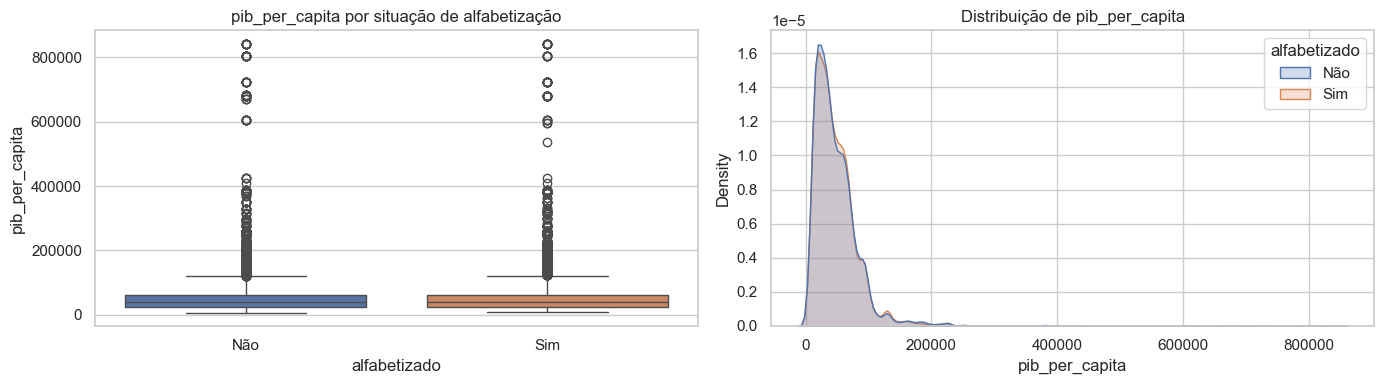

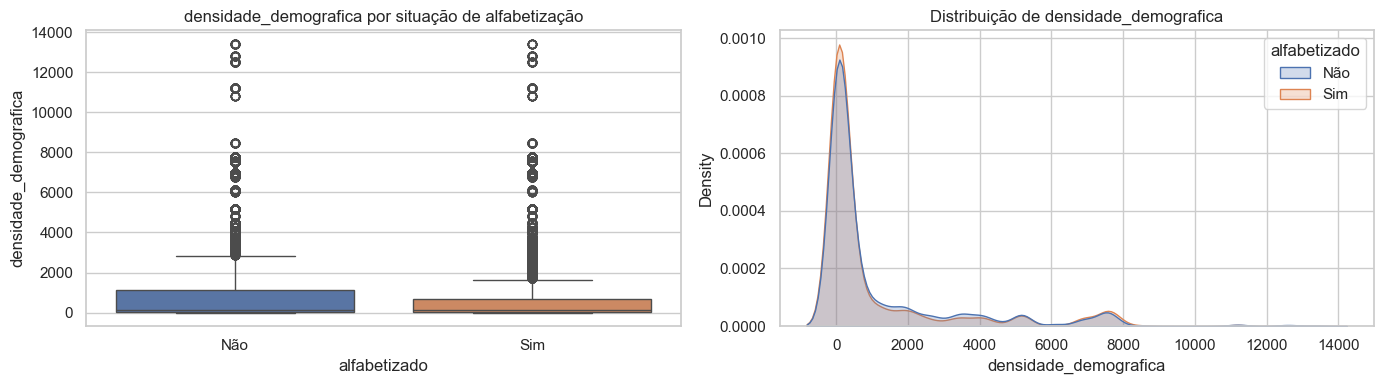

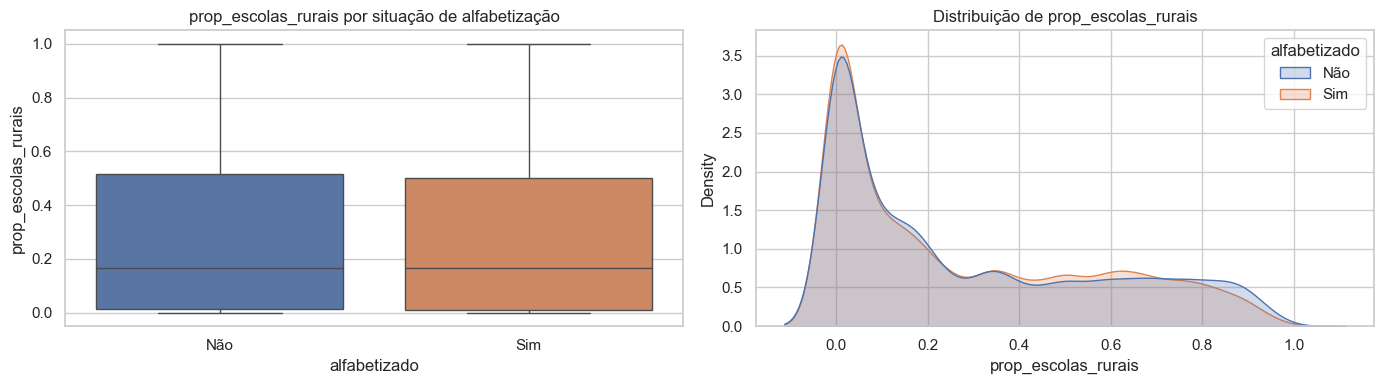

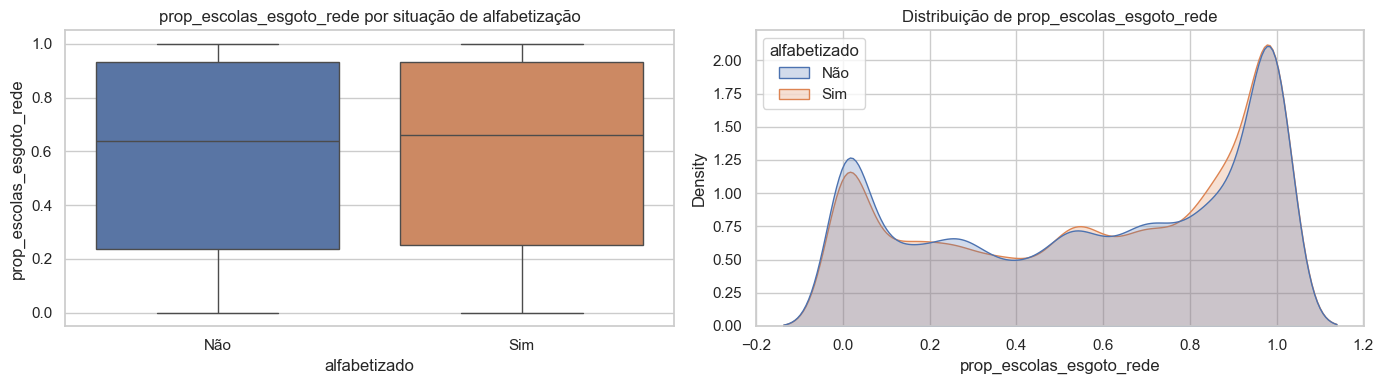

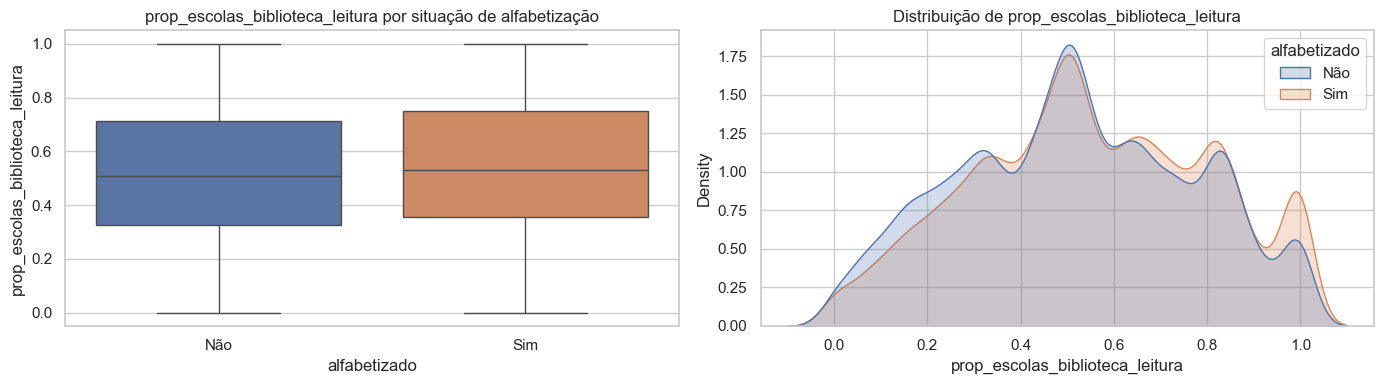

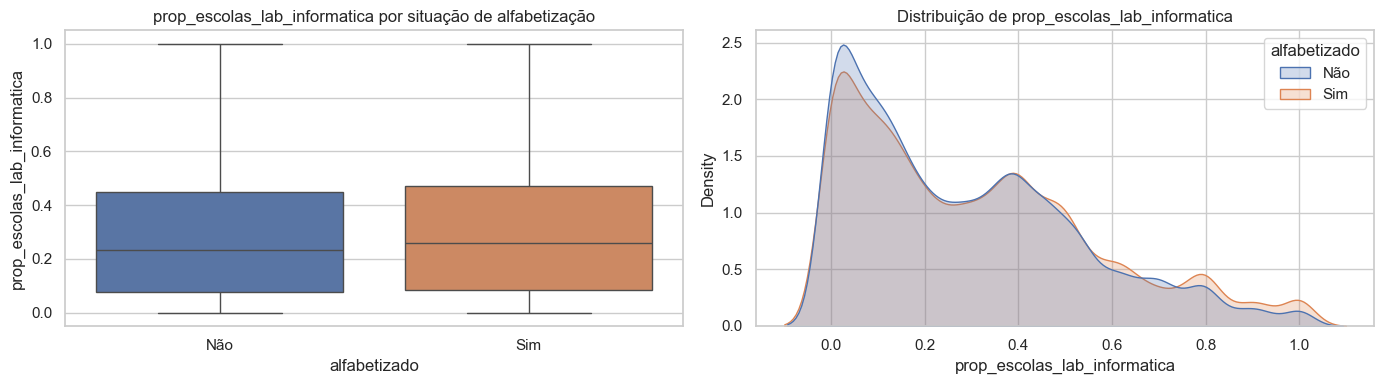

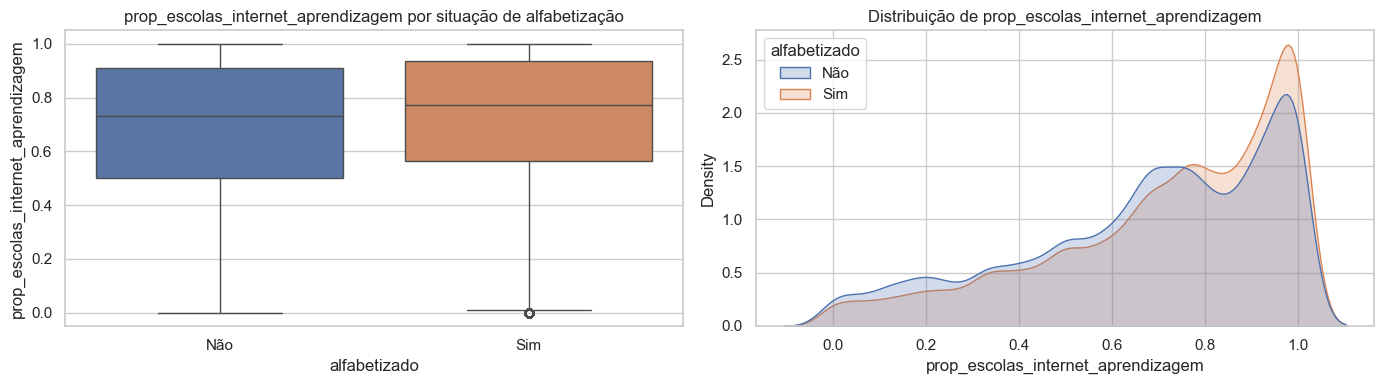

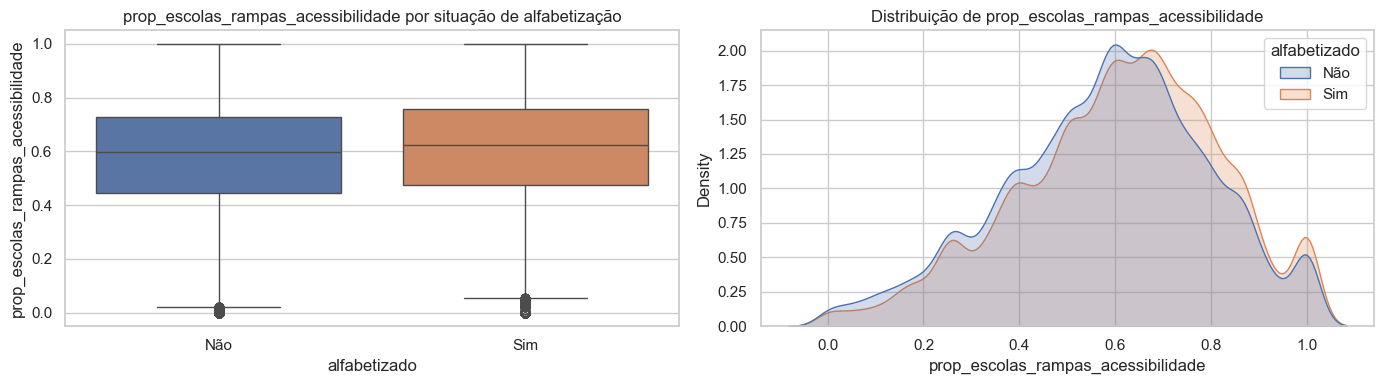

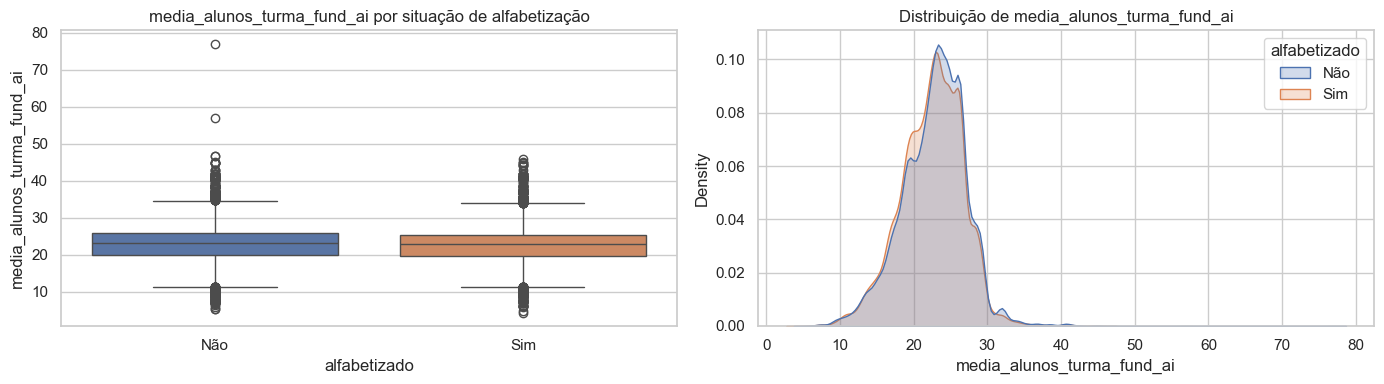

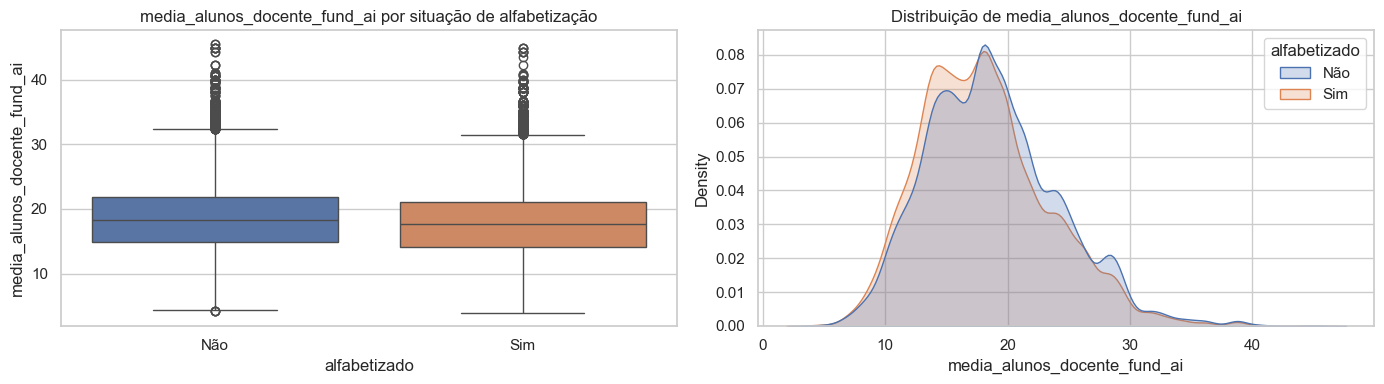

In [35]:
var_numericas_selecionadas = ["pib_per_capita", "densidade_demografica", "prop_escolas_rurais","prop_escolas_esgoto_rede", 
                              "prop_escolas_biblioteca_leitura","prop_escolas_lab_informatica","prop_escolas_internet_aprendizagem",
                              "prop_escolas_rampas_acessibilidade","media_alunos_turma_fund_ai","media_alunos_docente_fund_ai"]

for coluna in var_numericas_selecionadas:

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    sns.boxplot(data=df_eda, x="alfabetizado", y=coluna, hue="alfabetizado", legend=False, ax=ax[0])
    ax[0].set_title(f"{coluna} por situação de alfabetização")

    sns.kdeplot(data=df_eda, x=coluna, hue="alfabetizado", fill=True, common_norm=False, ax=ax[1])
    ax[1].set_title(f"Distribuição de {coluna}")

    plt.tight_layout()
    plt.show()

### 4.3 Correlação entre variáveis numéricas

A correlação entre as variáveis numéricas foi avaliada utilizando o coeficiente de Spearman.

Essa medida foi escolhida por ser adequada para dados com distribuições assimétricas, presença de valores extremos e possíveis relações monotônicas não necessariamente lineares.

A matriz de correlação mostra a existência de alguns grupos de variáveis relacionadas entre si.

Destacam-se associações entre variáveis de porte municipal, como população, densidade demográfica e quantidade de escolas, além de relações entre indicadores de infraestrutura escolar, como acesso à internet, banda larga e internet voltada para aprendizagem.

Também são observadas relações entre indicadores relacionados ao tamanho das turmas e quantidade de alunos por docente.

Essas correlações devem ser consideradas na etapa de engenharia de atributos, pois variáveis muito semelhantes podem fornecer informação redundante ao modelo.

In [38]:
df_eda["alfabetizado_bin"] = (
    df_eda["alfabetizado"]
    .map({
        "Não": 0,
        "Sim": 1
    })
)

In [39]:
var_correlacao = ["pib_per_capita", "populacao_2022", "area_km2", "densidade_demografica", "qtd_escolas_censo",
                  "prop_escolas_rurais", "prop_escolas_agua_potavel", "prop_escolas_esgoto_rede", "prop_escolas_biblioteca_leitura",
                  "prop_escolas_lab_informatica", "prop_escolas_internet", "prop_escolas_internet_aprendizagem",
                  "prop_escolas_banda_larga", "prop_escolas_rampas_acessibilidade", "media_alunos_turma_fund_ai",
                  "media_alunos_docente_fund_ai", "media_prop_salas_climatizadas", "alfabetizado_bin"]

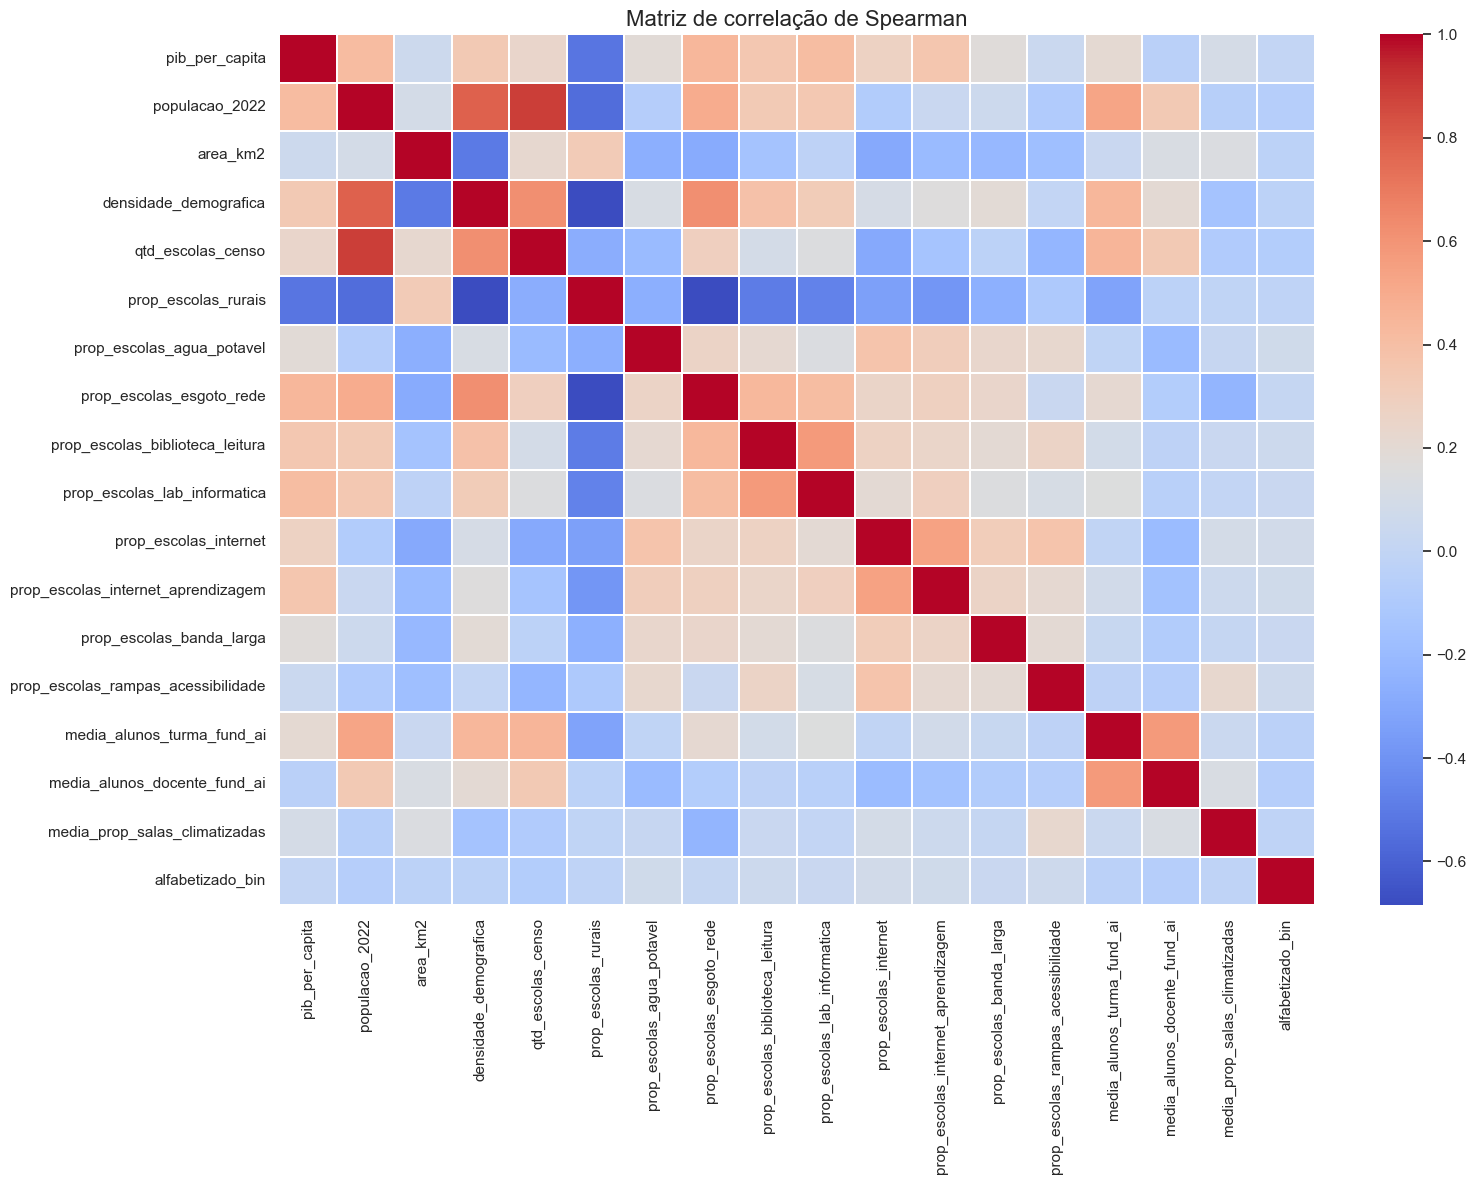

In [41]:
matriz_corr = (df_eda[var_correlacao].corr(method="spearman"))

plt.figure(figsize=(16, 12))

sns.heatmap(matriz_corr, cmap="coolwarm", linewidths=0.3)

plt.title("Matriz de correlação de Spearman", fontsize=16)

plt.tight_layout()
plt.show()

### 4.4 Associação das variáveis numéricas com a alfabetização

A associação individual entre as variáveis numéricas e a variável alvo foi avaliada por meio da correlação de Spearman com a representação binária de `alfabetizado`.

De forma geral, os coeficientes encontrados apresentam baixa magnitude, permanecendo aproximadamente entre -0,08 e 0,08.

As maiores associações positivas foram observadas em variáveis relacionadas à infraestrutura escolar, como:

- proporção de escolas com acesso à internet;
- proporção de escolas com internet voltada para aprendizagem;
- proporção de escolas com água potável;
- proporção de escolas com rampas de acessibilidade;
- proporção de escolas com biblioteca ou sala de leitura.

Por outro lado, algumas variáveis apresentaram associação negativa, entre elas:

- quantidade de escolas no contexto municipal;
- população do município;
- média de alunos por docente;
- média de alunos por turma;
- densidade demográfica.

Entretanto, mesmo as maiores correlações apresentam valores absolutos reduzidos.

Dessa forma, não há evidência de que uma única variável numérica possua forte capacidade de explicar isoladamente a alfabetização.

Esse resultado reforça a hipótese de que o desempenho dos alunos está associado à interação entre múltiplos fatores, justificando posteriormente o uso de modelos capazes de capturar relações não lineares e interações entre atributos.

In [ ]:
corr_target = (matriz_corr["alfabetizado_bin"].drop("alfabetizado_bin").sort_values(key=abs, ascending=False))

corr_target

prop_escolas_internet                 0.083264
qtd_escolas_censo                    -0.076717
prop_escolas_internet_aprendizagem    0.076397
prop_escolas_agua_potavel             0.075505
media_alunos_docente_fund_ai         -0.065528
prop_escolas_rampas_acessibilidade    0.063183
populacao_2022                       -0.061807
prop_escolas_biblioteca_leitura       0.057285
media_alunos_turma_fund_ai           -0.038508
prop_escolas_banda_larga              0.034286
prop_escolas_lab_informatica          0.034156
densidade_demografica                -0.032659
area_km2                             -0.027187
prop_escolas_esgoto_rede              0.016340
media_prop_salas_climatizadas        -0.016143
prop_escolas_rurais                  -0.015722
pib_per_capita                        0.003653
Name: alfabetizado_bin, dtype: float64

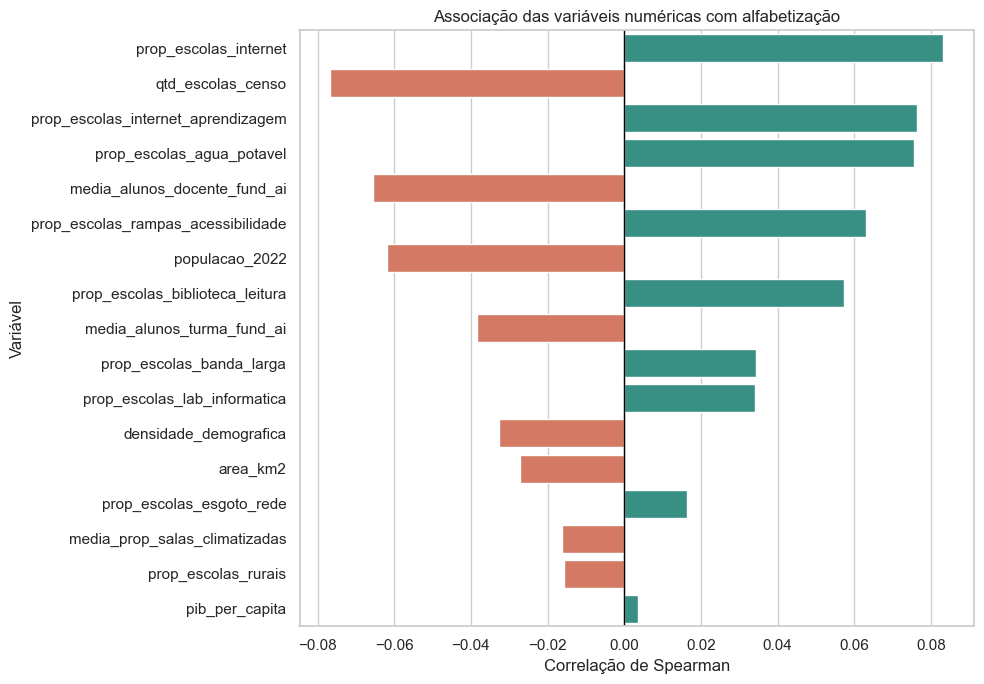

In [ ]:
plt.figure(figsize=(10, 7))

cores = ["#2a9d8f" if valor >= 0 else "#e76f51"
         for valor in corr_target.values]

sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index, palette=cores, legend=False)

plt.axvline(0, color="black", linewidth=1)

plt.title("Associação das variáveis numéricas com alfabetização")

plt.xlabel("Correlação de Spearman")
plt.ylabel("Variável")

plt.tight_layout()
plt.show()

### 4.5 Síntese da análise das variáveis numéricas

A análise das variáveis numéricas revelou forte heterogeneidade territorial e socioeconômica, além de diferenças importantes na disponibilidade de infraestrutura educacional.

Apesar dessas diferenças estruturais, as distribuições entre alunos alfabetizados e não alfabetizados apresentam elevada sobreposição e as correlações individuais com a variável alvo são baixas.

Portanto, as evidências obtidas até esta etapa indicam que a alfabetização não parece ser explicada por um único fator numérico, mas possivelmente pela combinação entre características econômicas, territoriais, educacionais e regionais.

Esses resultados serão considerados nas etapas posteriores de engenharia de atributos e modelagem.

## 5. Análise das variáveis categóricas

Nesta seção são analisadas as variáveis categóricas do dataset com o objetivo de identificar diferenças na taxa de alfabetização entre grupos, padrões territoriais e possíveis relações entre características educacionais e a variável alvo.

Além da análise descritiva, será avaliada a força de associação entre cada variável categórica e `alfabetizado`, permitindo identificar atributos potencialmente relevantes para a etapa de modelagem.

Variáveis utilizadas apenas como identificadores não serão consideradas nesta análise.

In [44]:
var_categoricas = ["ano", "caderno", "rede", "presenca", "preenchimento_caderno", "sigla_uf", "regiao"]

var_categoricas

['ano',
 'caderno',
 'rede',
 'presenca',
 'preenchimento_caderno',
 'sigla_uf',
 'regiao']

### 5.1 Visão geral das variáveis categóricas

A análise inicial das variáveis categóricas mostrou que o dataset possui poucas categorias na maior parte dos atributos, o que facilita a interpretação dos padrões.

As variáveis `ano`, `rede`, `presenca` e `preenchimento_caderno` possuem apenas duas categorias, enquanto `caderno` possui quatro categorias e `regiao` possui cinco.

A variável `sigla_uf` apresenta maior cardinalidade, com 26 Unidades Federativas representadas na base.

Também foi observada concentração relevante da amostra em algumas categorias, principalmente na rede municipal, que representa a maior parte dos registros analisados.

In [45]:
resumo_categoricas = []

for coluna in var_categoricas:
    resumo_categoricas.append({
        "variavel": coluna,
        "categorias": df_eda[coluna].nunique(),
        "categoria_mais_frequente": df_eda[coluna].mode().iloc[0],
        "frequencia_maior_categoria": df_eda[coluna].value_counts().iloc[0]
    })

resumo_categoricas = pd.DataFrame(resumo_categoricas)

resumo_categoricas

,variavel,categorias,categoria_mais_frequente,frequencia_maior_categoria
0,ano,2,2024,29431
1,caderno,4,1,22814
2,rede,2,Municipal,51402
3,presenca,2,Presente,48050
4,preenchimento_caderno,2,Prova preenchida,48021
5,sigla_uf,26,MG,6168
6,regiao,5,Sudeste,18050


In [46]:
def resumo_categorica(df, coluna):
    resumo = (
        df.groupby(
            coluna,
            dropna=False
        )["alfabetizado_bin"]
        .agg(
            quantidade="size",
            taxa_alfabetizacao="mean"
        )
        .reset_index()
    )

    resumo["percentual_amostra"] = (
        resumo["quantidade"]
        / len(df)
        * 100
    )

    resumo["taxa_alfabetizacao"] *= 100

    return resumo.sort_values(
        "taxa_alfabetizacao",
        ascending=False
    )

### 5.2 Taxa de alfabetização por categorias

A comparação das taxas de alfabetização entre as categorias revelou diferenças de intensidade variável entre os grupos analisados.

A variável `ano` apresentou pouca variação, com a taxa de alfabetização passando de 48,23% em 2023 para 49,62% em 2024, indicando uma pequena evolução no período.

Em relação à rede de ensino, a rede estadual apresentou taxa de aproximadamente 51,52%, enquanto a rede municipal apresentou 48,62%. A diferença é moderada, sendo importante considerar que aproximadamente 89% da amostra pertence à rede municipal.

A variável `caderno` apresentou comportamento distinto entre suas categorias. Os cadernos 1, 10 e 11 registraram taxas próximas de 50%, enquanto o caderno 12 apresentou apenas 12,81% de alfabetização. Essa diferença sugere a existência de alguma característica específica associada a essa categoria e deverá ser investigada antes da modelagem.

As maiores diferenças foram observadas nas variáveis `presenca` e `preenchimento_caderno`. Entre os alunos presentes ou com prova preenchida, a taxa de alfabetização foi próxima de 58,8%. Em contrapartida, os alunos ausentes ou com prova não preenchida apresentaram taxa de alfabetização igual a 0%.

Também foram identificadas diferenças territoriais. Sudeste, Centro-Oeste e Sul apresentaram taxas próximas de 50%, enquanto a região Norte apresentou 38,50%, valor consideravelmente inferior às demais regiões.

De forma geral, as análises indicam que as características territoriais e algumas variáveis relacionadas ao processo de aplicação da avaliação apresentam diferenças mais expressivas entre as categorias do que aquelas observadas em variáveis como ano e rede.

,ano,quantidade,taxa_alfabetizacao,percentual_amostra
1,2024,29431,49.62,51.0
0,2023,28281,48.23,49.0


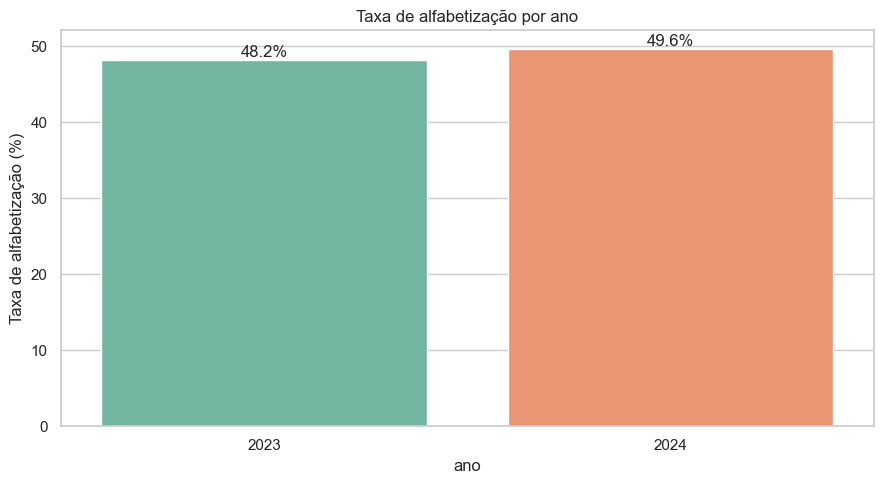

,caderno,quantidade,taxa_alfabetizacao,percentual_amostra
1,10,16227,51.61,28.12
2,11,16134,51.26,27.96
0,1,22814,49.42,39.53
3,12,2537,12.81,4.40


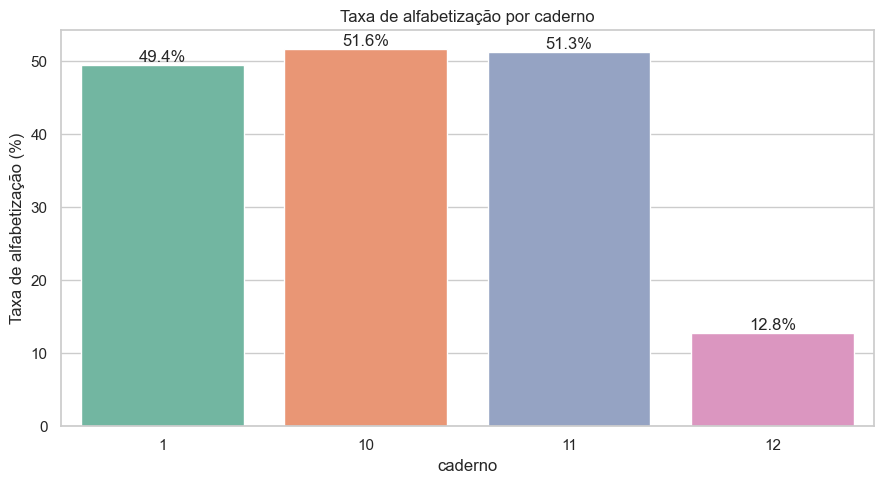

,rede,quantidade,taxa_alfabetizacao,percentual_amostra
0,Estadual,6310,51.52,10.93
1,Municipal,51402,48.62,89.07


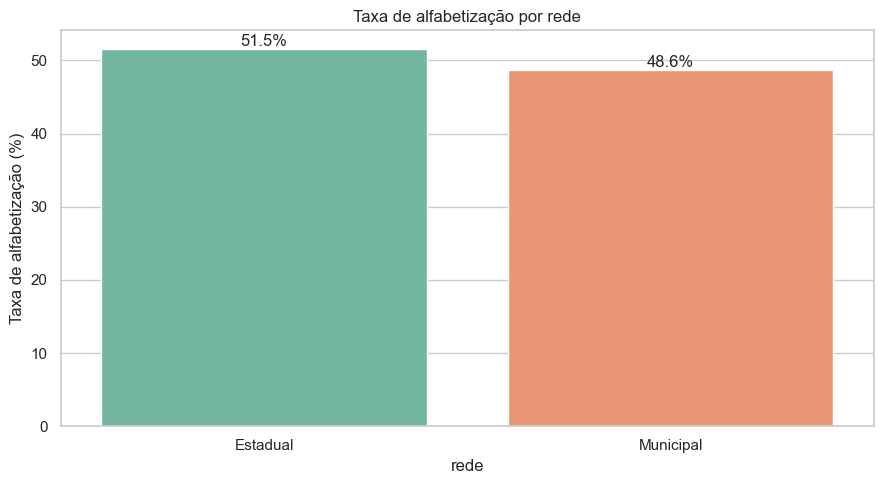

,presenca,quantidade,taxa_alfabetizacao,percentual_amostra
1,Presente,48050,58.78,83.26
0,Ausente,9662,0.00,16.74


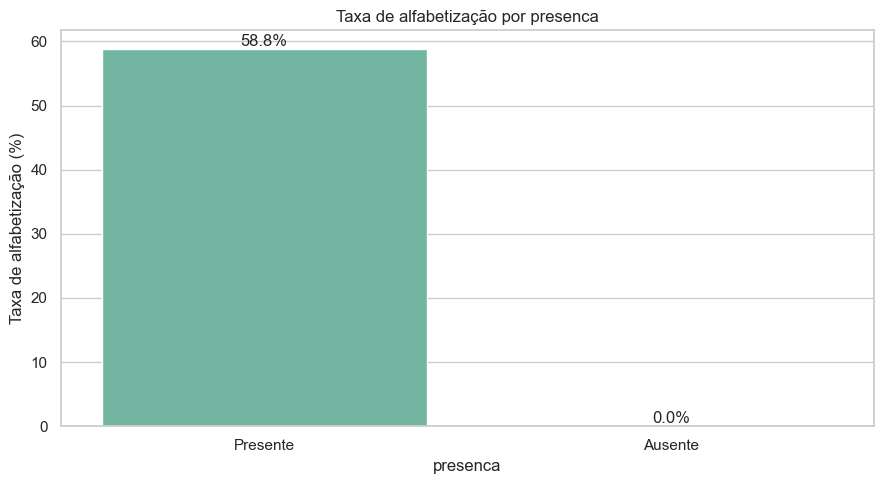

,preenchimento_caderno,quantidade,taxa_alfabetizacao,percentual_amostra
1,Prova preenchida,48021,58.82,83.21
0,Prova não preenchida,9691,0.00,16.79


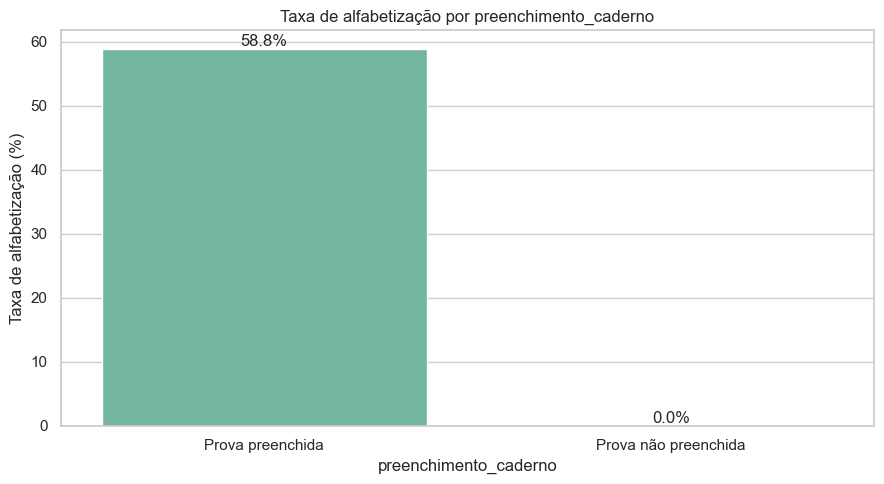

,regiao,quantidade,taxa_alfabetizacao,percentual_amostra
3,Sudeste,18050,51.22,31.28
0,Centro-Oeste,5836,51.15,10.11
4,Sul,10927,50.40,18.93
1,Nordeste,16206,48.93,28.08
2,Norte,6693,38.50,11.60


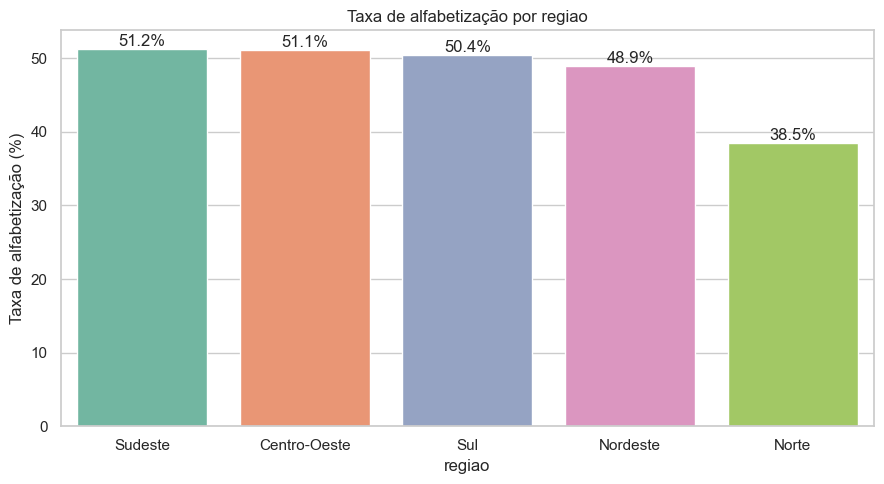

In [47]:
var_categoricas_principais = ["ano", "caderno", "rede", "presenca", "preenchimento_caderno", "regiao"]

for coluna in var_categoricas_principais:

    resumo = resumo_categorica(
        df_eda,
        coluna
    )

    display(resumo.round(2))

    plt.figure(figsize=(9, 5))

    ax = sns.barplot(
        data=resumo,
        x=coluna,
        y="taxa_alfabetizacao",
        hue=coluna,
        legend=False,
        palette="Set2"
    )

    plt.title(
        f"Taxa de alfabetização por {coluna}"
    )

    plt.xlabel(coluna)
    plt.ylabel("Taxa de alfabetização (%)")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%"
        )

    plt.tight_layout()
    plt.show()

### 5.3 Análise por Unidade Federativa

A análise por Unidade Federativa evidencia uma heterogeneidade territorial ainda maior.

As taxas de alfabetização variam de pouco mais de 30% em alguns estados até valores superiores a 50% em outros, com destaque para o Ceará, que apresenta a maior taxa observada na amostra.

Estados como Rio Grande do Norte, Bahia e Sergipe aparecem entre os menores percentuais observados.

Esse resultado reforça a existência de diferenças territoriais relevantes no fenômeno da alfabetização. Entretanto, as taxas devem ser interpretadas conjuntamente com a quantidade de observações disponível em cada Unidade Federativa, evitando atribuir as diferenças exclusivamente ao efeito geográfico.

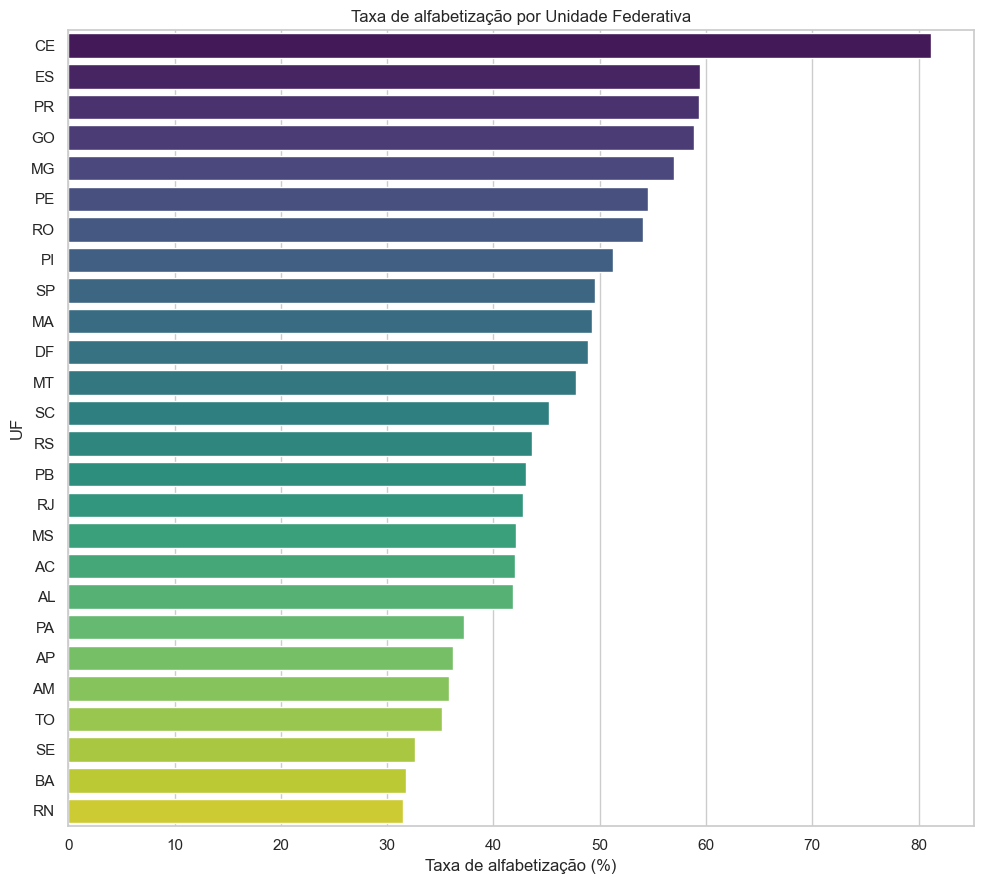

In [48]:
resumo_uf = resumo_categorica(
    df_eda,
    "sigla_uf"
)

plt.figure(figsize=(10, 9))

sns.barplot(
    data=resumo_uf,
    x="taxa_alfabetizacao",
    y="sigla_uf",
    hue="sigla_uf",
    legend=False,
    palette="viridis"
)

plt.title(
    "Taxa de alfabetização por Unidade Federativa"
)

plt.xlabel("Taxa de alfabetização (%)")
plt.ylabel("UF")

plt.tight_layout()
plt.show()

In [49]:
resumo_uf[
    [
        "sigla_uf",
        "quantidade",
        "percentual_amostra",
        "taxa_alfabetizacao"
    ]
].round(2)

,sigla_uf,quantidade,percentual_amostra,taxa_alfabetizacao
5,CE,2860,4.96,81.15
7,ES,1461,2.53,59.41
17,PR,4392,7.61,59.36
8,GO,2458,4.26,58.83
10,MG,6168,10.69,56.96
15,PE,2391,4.14,54.54
20,RO,710,1.23,54.08
16,PI,1022,1.77,51.27
24,SP,6003,10.40,49.53
9,MA,2237,3.88,49.31


### 5.4 Força de associação com a variável alvo

A força de associação entre as variáveis categóricas e `alfabetizado` foi avaliada utilizando o coeficiente de Cramér's V.

As maiores associações foram observadas em `preenchimento_caderno` (0,440) e `presenca` (0,439), apresentando valores substancialmente superiores aos demais atributos.

A variável `sigla_uf` apresentou associação de aproximadamente 0,226, seguida por `caderno`, com aproximadamente 0,156.

Já `regiao`, `rede` e `ano` apresentaram associações de menor magnitude.

Embora os testes de qui-quadrado apresentem significância estatística para as variáveis avaliadas, o tamanho da amostra torna especialmente importante considerar também a magnitude da associação. Dessa forma, o Cramér's V é utilizado como principal referência para avaliar a relevância prática dessas relações.

In [50]:
from scipy.stats import chi2_contingency

In [51]:
def cramers_v(x, y):
    tabela = pd.crosstab(x, y)

    chi2 = chi2_contingency(tabela)[0]

    n = tabela.values.sum()

    r, k = tabela.shape

    denominador = min(k - 1, r - 1)

    if denominador == 0:
        return np.nan

    return np.sqrt(
        (chi2 / n) / denominador
    )

In [52]:
associacoes_categoricas = []

for coluna in var_categoricas:

    tabela = pd.crosstab(
        df_eda[coluna],
        df_eda["alfabetizado"]
    )

    chi2, p_value, _, _ = chi2_contingency(
        tabela
    )

    v_cramer = cramers_v(
        df_eda[coluna],
        df_eda["alfabetizado"]
    )

    associacoes_categoricas.append({
        "variavel": coluna,
        "cramers_v": v_cramer,
        "p_value": p_value
    })

associacoes_categoricas = (
    pd.DataFrame(associacoes_categoricas)
    .sort_values(
        "cramers_v",
        ascending=False
    )
)

associacoes_categoricas

,variavel,cramers_v,p_value
4,preenchimento_caderno,0.439755,0.000000e+00
3,presenca,0.438964,0.000000e+00
5,sigla_uf,0.225710,0.000000e+00
1,caderno,0.156217,4.466371e-305
6,regiao,0.077871,1.788511e-74
2,rede,0.018040,1.464929e-05
0,ano,0.013875,8.587406e-04


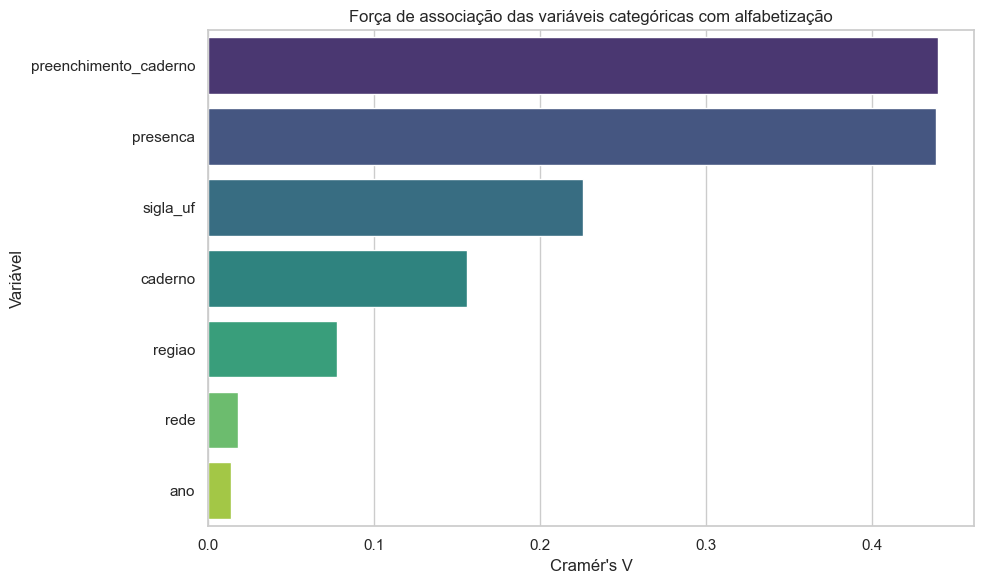

In [53]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=associacoes_categoricas,
    x="cramers_v",
    y="variavel",
    hue="variavel",
    legend=False,
    palette="viridis"
)

plt.title(
    "Força de associação das variáveis categóricas com alfabetização"
)

plt.xlabel("Cramér's V")
plt.ylabel("Variável")

plt.tight_layout()
plt.show()

### 5.5 Avaliação de possíveis variáveis com data leakage

Os resultados observados para `presenca` e `preenchimento_caderno` exigem atenção especial.

Ambas apresentaram Cramér's V próximo de 0,44 e taxa de alfabetização igual a 0% para alunos ausentes ou com prova não preenchida.

Esse comportamento sugere que essas variáveis podem estar relacionadas ao próprio processo utilizado para determinar ou registrar a situação de alfabetização, e não apenas a características disponíveis previamente para previsão.

Por esse motivo, `presenca` e `preenchimento_caderno` serão consideradas potenciais fontes de **data leakage** e sua utilização como preditores deverá ser evitada ou avaliada em cenários separados durante a modelagem.

### 5.6 Síntese da análise das variáveis categóricas

As variáveis categóricas apresentaram padrões mais evidentes de associação com a alfabetização do que as variáveis numéricas analisadas isoladamente.

Os principais resultados foram:

- pequena diferença temporal entre 2023 e 2024;
- diferença moderada entre redes estadual e municipal;
- comportamento atípico associado ao caderno 12;
- diferenças territoriais relevantes entre regiões e Unidades Federativas;
- forte associação de `presenca` e `preenchimento_caderno` com o target, acompanhada de risco de data leakage;
- maior relevância de `sigla_uf` em comparação com a variável regional mais agregada.

Os resultados reforçam a importância de considerar características territoriais na modelagem e indicam que variáveis operacionais diretamente relacionadas à aplicação da avaliação devem ser tratadas com cautela.

## 6. Investigações complementares

### 6.1 Investigação do comportamento do caderno 12

Durante a análise das variáveis categóricas, o `caderno 12` apresentou uma taxa de alfabetização significativamente inferior às demais categorias.

Enquanto os cadernos 1, 10 e 11 apresentaram taxas próximas de 50%, o caderno 12 registrou apenas aproximadamente 12,8% de alunos alfabetizados.

Para compreender essa diferença, foi analisada a relação entre o tipo de caderno e outras variáveis operacionais e contextuais.

#### Relação com presença e preenchimento da avaliação

A principal diferença associada ao caderno 12 foi identificada nas variáveis `presenca` e `preenchimento_caderno`.

Nos cadernos 1, 10 e 11, aproximadamente 84% a 87% dos alunos estavam presentes durante a avaliação.

No caderno 12, entretanto, apenas **20,42% dos alunos estavam presentes**, enquanto **79,58% foram registrados como ausentes**.

O mesmo comportamento foi observado no preenchimento da prova:

- aproximadamente 84% a 87% dos registros dos cadernos 1, 10 e 11 possuem prova preenchida;
- no caderno 12, apenas **20,22% apresentam prova preenchida**, enquanto **79,78% não possuem preenchimento**.

Esse resultado explica grande parte da baixa taxa de alfabetização observada no caderno 12, uma vez que as análises anteriores mostraram que alunos ausentes ou com prova não preenchida apresentam taxa de alfabetização igual a 0%.

Portanto, a baixa alfabetização observada para o caderno 12 não deve ser interpretada como evidência de maior dificuldade ou menor desempenho associado ao conteúdo desse caderno. O comportamento está fortemente relacionado às condições de presença e realização da avaliação.

In [54]:
caderno_presenca = pd.crosstab(
    df_eda["caderno"],
    df_eda["presenca"],
    normalize="index"
).mul(100).round(2)

caderno_presenca

presenca,Ausente,Presente
caderno,,
1,15.60,84.40
10,12.71,87.29
11,12.53,87.47
12,79.58,20.42


In [55]:
caderno_preenchimento = pd.crosstab(
    df_eda["caderno"],
    df_eda["preenchimento_caderno"],
    normalize="index"
).mul(100).round(2)

caderno_preenchimento

preenchimento_caderno,Prova não preenchida,Prova preenchida
caderno,,
1,15.66,84.34
10,12.74,87.26
11,12.56,87.44
12,79.78,20.22


#### Distribuição temporal

O caderno 12 está presente nos dois anos avaliados, com aproximadamente:

- **59,24% dos registros em 2023**
- **40,76% dos registros em 2024**

Apesar de existir maior concentração em 2023, essa diferença não é suficiente para explicar isoladamente o comportamento atípico observado na taxa de alfabetização.

In [56]:
caderno_ano = pd.crosstab(
    df_eda["caderno"],
    df_eda["ano"],
    normalize="index"
).mul(100).round(2)

caderno_ano

ano,2023,2024
caderno,,
1,52.81,47.19
10,45.10,54.90
11,45.94,54.06
12,59.24,40.76


#### Distribuição por rede de ensino

A distribuição do caderno 12 entre as redes estadual e municipal é bastante semelhante à observada nos demais cadernos.

Aproximadamente 89% dos registros pertencem à rede municipal e 11% à rede estadual.

Dessa forma, não foram identificadas evidências de que a rede de ensino seja responsável pelo comportamento atípico do caderno 12.

In [57]:
caderno_rede = pd.crosstab(
    df_eda["caderno"],
    df_eda["rede"],
    normalize="index"
).mul(100).round(2)

caderno_rede

rede,Estadual,Municipal
caderno,,
1,10.74,89.26
10,10.98,89.02
11,11.14,88.86
12,11.04,88.96


#### Distribuição regional

A distribuição regional do caderno 12 também não apresenta concentração suficiente para explicar isoladamente sua baixa taxa de alfabetização.

Embora existam pequenas diferenças em relação aos demais cadernos, como maior participação das regiões Norte e Sul e menor participação do Nordeste, os registros permanecem distribuídos entre todas as regiões brasileiras.

Portanto, o padrão identificado parece estar muito mais relacionado às variáveis operacionais de presença e preenchimento da avaliação do que à localização regional.

In [58]:
caderno_regiao = pd.crosstab(
    df_eda["caderno"],
    df_eda["regiao"],
    normalize="index"
).mul(100).round(2)

caderno_regiao

regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
caderno,,,,,
1,10.19,28.58,10.80,31.04,19.39
10,10.11,27.98,12.04,31.76,18.11
11,10.01,28.51,11.80,31.28,18.41
12,10.05,21.48,14.66,30.35,23.45


### 6.2 Conclusão da investigação do caderno

A investigação indica que o comportamento atípico do `caderno 12` está fortemente associado à ausência dos alunos e ao não preenchimento da avaliação.

Aproximadamente 80% dos registros dessa categoria correspondem a alunos ausentes ou com prova não preenchida, enquanto nos demais cadernos esse percentual permanece próximo de 13% a 16%.

Esse padrão explica a taxa de alfabetização significativamente inferior observada para o caderno 12 e indica que a variável `caderno` pode estar capturando características operacionais do processo de avaliação.

Consequentemente, sua utilização como variável preditora deverá ser avaliada com cautela, especialmente devido à relação indireta com `presenca` e `preenchimento_caderno`, que já foram identificadas como potenciais fontes de data leakage.